In [1]:
# read data yearky in pickle file
import pickle
import sys
import os
import numpy as np
maindir = os.getcwd()
sys.path.append(maindir+"/ForceSMIP")

with open('data_yearly.pickle', 'rb') as f:
    data = pickle.load(f)

In [2]:
data_anomaly_yearly = data['dic_data_yearly']
data_forced_response_yearly = data['dic_forced_response_yearly']

In [3]:
import torch

def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = x[m]/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = y[m]/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, x[m].to(torch.float32) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, y[m].to(torch.float32) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train


def reshape_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    x_train = {}
    y_train = {}
    
    for idx_m,m in enumerate(x.keys()):
        
        x_train[m] = x[m].reshape(x[m].shape[0],x[m].shape[1],x[m].shape[2]*x[m].shape[3])
        y_train[m] = y[m].reshape(x[m].shape[0],x[m].shape[1],x[m].shape[2]*x[m].shape[3])
        print(f'  x_train shape: {x_train[m].shape}')
        print(f'  y_train shape: {y_train[m].shape}')
    return x_train, y_train

In [4]:
x_train_yearly_stack, y_train_yearly_stack  = merge_training_data(data_anomaly_yearly,data_forced_response_yearly,dtype=torch.float32)

x_train_yearly = x_train_yearly_stack.view(-1,x_train_yearly_stack.shape[2])
y_train_yearly = y_train_yearly_stack.view(-1,y_train_yearly_stack.shape[2])

  x_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([75, 221, 10368])
  x_train shape: torch.Size([105, 221, 10368])
  x_train shape: torch.Size([155, 221, 10368])
  x_train shape: torch.Size([185, 221, 10368])


# Get Test data

In [5]:
import netCDF4 as netcdf

# read the test data
PATH_EVAL = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/Evaluation-Tier1/'


DIR_LIST_TEST = os.listdir(PATH_EVAL)

test_models = ['B', 'D', 'E', 'G', 'J']

data_test = np.zeros((len(test_models), 876, 72, 144), dtype=np.float32)

for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_') and file.endswith('.nc'):
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_EVAL, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[9] in test_models:
            # find position of file[9] in test_models
            idx_test = test_models.index(file[9])
            print(f'  Found test data for {file[9]} at index {idx_test}')
            data_test[idx_test,:,:,:] = np.array(netcdf_file.variables['tas']) 
        
            for i in range(12):
                data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_test[idx_test,:,:,:].shape}')

  Processing 6/81: tas_mon_1F.195001-202212.nc
  Processing 12/81: tas_mon_1C.195001-202212.nc


/tmp/ipykernel_24305/3695116169.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  time = np.array(netcdf_file.variables['time'])
/tmp/ipykernel_24305/3695116169.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  longitude = np.array(netcdf_file.variables['lon'])
/tmp/ipykernel_24305/3695116169.py:23: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To

  Processing 16/81: tas_mon_1H.195001-202212.nc
  Processing 26/81: tas_mon_1G.195001-202212.nc
  Found test data for G at index 3


/tmp/ipykernel_24305/3695116169.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data_test[idx_test,:,:,:] = np.array(netcdf_file.variables['tas'])


  Tas shape: (876, 72, 144)
  Processing 40/81: tas_mon_1D.195001-202212.nc
  Found test data for D at index 1
  Tas shape: (876, 72, 144)
  Processing 52/81: tas_mon_1J.195001-202212.nc
  Found test data for J at index 4
  Tas shape: (876, 72, 144)
  Processing 58/81: tas_mon_1A.195001-202212.nc
  Processing 60/81: tas_mon_1E.195001-202212.nc
  Found test data for E at index 2
  Tas shape: (876, 72, 144)
  Processing 71/81: tas_mon_1B.195001-202212.nc
  Found test data for B at index 0
  Tas shape: (876, 72, 144)
  Processing 77/81: tas_mon_1I.195001-202212.nc


In [6]:
# Read the ground truth data

PATH_GROUND_TRUTH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ensmeans-Tier1'

DIR_LIST_GROUND_TRUTH = os.listdir(PATH_GROUND_TRUTH)

data_ground_truth_test = np.zeros((len(test_models), 876, 72, 144), dtype=np.float32)

for idx_r, file in enumerate(DIR_LIST_GROUND_TRUTH):

    if file.__contains__('.tas.'):
        
        print(f'  Processing {idx_r+1}: {file}')

        # read the ground truth data
        file_path = os.path.join(PATH_GROUND_TRUTH, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[1] in test_models:
            # find position of file[1] in test_models
            idx_test = test_models.index(file[1])
            print(f'  Found test data for {file[1]} at index {idx_test}')
            data_ground_truth_test[idx_test,:,:,:] = np.array(netcdf_file.variables['arr_EM'])

            for i in range(12):
                data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_ground_truth_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_ground_truth_test[idx_test,:,:,:].shape}')

  Processing 7: 1A.tas.EM.1950-2022.nc
  Processing 15: 1B.tas.EM.1950-2022.nc
  Found test data for B at index 0


/tmp/ipykernel_24305/3495087413.py:20: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  time = np.array(netcdf_file.variables['time'])
/tmp/ipykernel_24305/3495087413.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  longitude = np.array(netcdf_file.variables['lon'])
/tmp/ipykernel_24305/3495087413.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To

  Tas shape: (876, 72, 144)
  Processing 23: 1C.tas.EM.1950-2022.nc
  Processing 31: 1D.tas.EM.1950-2022.nc
  Found test data for D at index 1
  Tas shape: (876, 72, 144)
  Processing 39: 1E.tas.EM.1950-2022.nc
  Found test data for E at index 2
  Tas shape: (876, 72, 144)
  Processing 47: 1F.tas.EM.1950-2022.nc
  Processing 55: 1G.tas.EM.1950-2022.nc
  Found test data for G at index 3
  Tas shape: (876, 72, 144)
  Processing 63: 1H.tas.EM.1950-2022.nc
  Processing 71: 1J.tas.EM.1950-2022.nc
  Found test data for J at index 4
  Tas shape: (876, 72, 144)


In [7]:
# Read the estimates of the other methods
# read the test data
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ForceSMIP-estimates-Tier1'

DIR_LIST_TEST = os.listdir(PATH_TEST)
data_estimates = np.zeros((30,len(test_models), 876, 72, 144), dtype=np.float32)


for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_'):

        # read the test data
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_TEST, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')


        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[5] in test_models:
            # find position of file[1] in test_models
            idx_test = test_models.index(file[5])
            print(f'  Found test data for {file[5]} at index {idx_test}')
            data_estimates[:,idx_test,:,:,:] = np.array(netcdf_file.variables['forced_component']) 

        print(f'  Tas shape: {data_estimates[:,idx_test,:,:,:].shape}')

lst_to_center = [8,9,14,24]

# center the methods that are not centered
for idx_m in lst_to_center:
    print(f'Centering data for method {idx_m}')
    for i in range(12):
        data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] = data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_estimates[idx_m,:, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

  Processing 51/80: tas_1A_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 52/80: tas_1B_1950_2022.nc
  Found test data for B at index 0


/tmp/ipykernel_24305/18826197.py:20: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  time = np.array(netcdf_file.variables['time'])
/tmp/ipykernel_24305/18826197.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  longitude = np.array(netcdf_file.variables['lon'])
/tmp/ipykernel_24305/18826197.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn

  Tas shape: (30, 876, 72, 144)
  Processing 53/80: tas_1C_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 54/80: tas_1D_1950_2022.nc
  Found test data for D at index 1
  Tas shape: (30, 876, 72, 144)
  Processing 55/80: tas_1E_1950_2022.nc
  Found test data for E at index 2
  Tas shape: (30, 876, 72, 144)
  Processing 56/80: tas_1F_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 57/80: tas_1G_1950_2022.nc
  Found test data for G at index 3
  Tas shape: (30, 876, 72, 144)
  Processing 58/80: tas_1H_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 59/80: tas_1I_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 60/80: tas_1J_1950_2022.nc
  Found test data for J at index 4
  Tas shape: (30, 876, 72, 144)
Centering data for method 8
Centering data for method 9
Centering data for method 14
Centering data for method 24


In [8]:
def yearly_average(x, months_per_year=12):
    """
    Compute the yearly average of a time series.
    Args:
        data: numpy array of shape (time, ...)
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        numpy array of shape (years, ...)
    """
    n_years = x.shape[1] // months_per_year
    data_reshaped = x.reshape(x.shape[0],n_years, months_per_year, x.shape[2],x.shape[3])
    return data_reshaped.mean(axis=2)

In [9]:
# Compute yearly averages for the test data
x_test = data_test.reshape(data_test.shape[0], data_test.shape[1], -1)
y_test = data_ground_truth_test.reshape(data_ground_truth_test.shape[0], data_ground_truth_test.shape[1], -1)
x_test_yearly = yearly_average(data_test, months_per_year=12)
y_test_yearly = yearly_average(data_ground_truth_test, months_per_year=12)

# transform to pytorch tensors and reshape
x_test_yearly = x_test_yearly.reshape(x_test_yearly.shape[0],x_test_yearly.shape[1],x_test_yearly.shape[2]*x_test_yearly.shape[3])
y_test_yearly = y_test_yearly.reshape(y_test_yearly.shape[0],y_test_yearly.shape[1],y_test_yearly.shape[2]*y_test_yearly.shape[3])

In [10]:
data_estimates_yearly = data_estimates.reshape((data_estimates.shape[0], data_estimates.shape[1], data_estimates.shape[2]//12, 12, -1))
data_estimates_yearly = np.nanmean(data_estimates_yearly, axis=3)

# compute mse of the other estimates
mse_estimates = np.zeros((data_estimates_yearly.shape[0],data_estimates_yearly.shape[1]))

for idx_r in range(data_estimates_yearly.shape[0]):
    mse_estimates[idx_r,:] = np.sqrt(np.mean((data_estimates_yearly[idx_r,:,:,:] - y_test_yearly) ** 2,axis=(1,2))) 
    print(f'  MSE estimates: {mse_estimates[idx_r,:]}')

  MSE estimates: [0.3708767  0.76184803 0.32120651 0.42573875 0.36297438]
  MSE estimates: [0.31422687 0.57667619 0.24059433 0.3127341  0.30820149]
  MSE estimates: [0.27296612 0.70761365 0.23452061 0.29515049 0.27288583]
  MSE estimates: [0.41958332 0.26345435 0.33542052 0.28473562 0.28350335]
  MSE estimates: [0.22750515 0.46762332 0.23152888 0.25804055 0.26351762]
  MSE estimates: [0.19806424 0.31416944 0.21652955 0.24898265 0.2441894 ]
  MSE estimates: [0.21705036 0.63489521 0.20965408 0.24261999 0.24459068]
  MSE estimates: [0.27461651 0.60792452 0.25935444 0.32759362 0.39957711]
  MSE estimates: [0.19176921 0.34745461 0.20301221 0.22336519 0.23584743]
  MSE estimates: [0.39808676 0.61394781 0.35952675 0.41795275 0.38969341]
  MSE estimates: [0.30238605 0.72864836 0.26559502 0.36354282 0.31569293]
  MSE estimates: [0.21946199 0.54224259 0.18590359 0.29149708 0.26371101]
  MSE estimates: [0.21665739 0.54131752 0.19710793 0.28298753 0.26177433]
  MSE estimates: [0.20829439 0.5897602

# Build the classifier for the training set

In [11]:
### Training dates 
years_train = np.arange(2100 - 1880 +1)

# year index to a scalar in [0,1]
years_train_idx_feature = years_train # normalize to [0,1] range

# get index of years 1950 - 2022
years_test = years_train[(years_train >= 1950-1880) & (years_train <= 2022-1880)]
years_test_idx_feature =  years_test


print("Training years:", years_train_idx_feature)
print("Test years:", years_test_idx_feature)

Training years: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220]
Test years: [ 70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87
 

# Train and test our classifier

In [12]:
from preprocessing import stack_models_and_runs

# test the classifier on the training data
# remove some samples from the training set
#train on the 3/4 of the training data for each model

data_anomaly_yearly_train = {}
data_anomaly_yearly_test = {}

data_forced_response_yearly_train = {}
data_forced_response_yearly_test = {}

for m in data_anomaly_yearly.keys():
    nb_samples = int(data_anomaly_yearly[m].shape[0] * 1.0)
    data_anomaly_yearly_train[m] = data_anomaly_yearly[m][:nb_samples,years_test_idx_feature,:]
    data_anomaly_yearly_test[m] = data_anomaly_yearly[m][nb_samples:,years_test_idx_feature,:]

    data_forced_response_yearly_train[m] = data_forced_response_yearly[m][:nb_samples,years_test_idx_feature,:]
    data_forced_response_yearly_test[m] = data_forced_response_yearly[m][nb_samples:,years_test_idx_feature,:]

# create the stacked training data
x_train_classifier, y_train_classifier  = merge_training_data(data_anomaly_yearly_train,data_forced_response_yearly_train,dtype=torch.float32)
x_train_classifier = x_train_classifier.view(-1,x_train_classifier.shape[2])
y_train_classifier = y_train_classifier.view(-1,y_train_classifier.shape[2])


# create the stacked test data
x_test_classifier, y_test_classifier  = merge_training_data(data_anomaly_yearly_test,data_forced_response_yearly_test,dtype=torch.float32)
# x_test_classifier = x_test_classifier.view(-1,x_test_classifier.shape[2])
# y_test_classifier = y_test_classifier.view(-1,y_test_classifier.shape[2])

  x_train shape: torch.Size([50, 73, 10368])
  x_train shape: torch.Size([75, 73, 10368])
  x_train shape: torch.Size([105, 73, 10368])
  x_train shape: torch.Size([155, 73, 10368])
  x_train shape: torch.Size([185, 73, 10368])
  x_train shape: torch.Size([0, 73, 10368])
  x_train shape: torch.Size([0, 73, 10368])
  x_train shape: torch.Size([0, 73, 10368])
  x_train shape: torch.Size([0, 73, 10368])
  x_train shape: torch.Size([0, 73, 10368])


In [13]:
models = list(data_anomaly_yearly_train.keys())

# define labels for each sample
labels = np.zeros((x_train_classifier.shape[0]), dtype=np.int64)
last_idx = 0

time_length = len(years_test_idx_feature)

# Assign labels based on the model index
for idx_m, m in enumerate(list(data_anomaly_yearly_train.keys())):
    # Get the indices for the current model

    labels[last_idx:last_idx+data_anomaly_yearly_train[m].shape[0]*time_length] = idx_m
    last_idx = last_idx+data_anomaly_yearly_train[m].shape[0]*time_length

In [14]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier

# # train a random forest algorithm
# rf_model = RandomForestClassifier(n_estimators=5, random_state=42)
# rf_model.fit(x_train_classifier.detach().numpy(), labels)

# train the classifier
# num_classes = len(data_anomaly_yearly_train.keys())
# num_features = time_length * x_train_classifier.shape[1]
# model = LogisticRegression(penalty='l2', C=100.0, multi_class='multinomial', solver='lbfgs', max_iter=1000)
# model = 

In [15]:
# test on the test data
predicted_labels_test = np.zeros((x_test.shape[0], x_test.shape[1]), dtype=np.int64)
predicted_proba_test = np.zeros((x_test.shape[0], x_test.shape[1],5), dtype=np.float64)

for i in range(x_test.shape[0]):
    predicted_labels_test[i,:] = rf_model.predict(x_test[i,:,:])  # reshape to (n_samples, n_features)
    predicted_proba_test[i,:,:] = rf_model.predict_proba(x_test[i,:,:])  # reshape to (n_samples, n_features)

In [16]:
predicted_proba_test

array([[[0. , 0.8, 0. , 0. , 0.2],
        [0.2, 0.6, 0. , 0. , 0.2],
        [0. , 0.6, 0.2, 0.2, 0. ],
        ...,
        [0.2, 0.4, 0. , 0. , 0.4],
        [0.2, 0.2, 0.2, 0. , 0.4],
        [0.2, 0.4, 0.4, 0. , 0. ]],

       [[0. , 0.4, 0.4, 0.2, 0. ],
        [0. , 0.2, 0. , 0.8, 0. ],
        [0. , 0.4, 0.2, 0.4, 0. ],
        ...,
        [0.4, 0.2, 0. , 0.2, 0.2],
        [0.2, 0.2, 0. , 0.2, 0.4],
        [0.4, 0. , 0.2, 0.2, 0.2]],

       [[0.6, 0.2, 0. , 0. , 0.2],
        [0. , 0.8, 0. , 0. , 0.2],
        [0. , 0.4, 0.6, 0. , 0. ],
        ...,
        [0. , 0.2, 0.2, 0. , 0.6],
        [0.2, 0.2, 0. , 0.2, 0.4],
        [0. , 0. , 0.4, 0. , 0.6]],

       [[0. , 0. , 0.2, 0.2, 0.6],
        [0.2, 0.4, 0. , 0. , 0.4],
        [0. , 0.4, 0. , 0.4, 0.2],
        ...,
        [0.8, 0. , 0. , 0. , 0.2],
        [0. , 0.4, 0.2, 0.2, 0.2],
        [0.2, 0.6, 0. , 0. , 0.2]],

       [[0.6, 0.2, 0.2, 0. , 0. ],
        [0. , 0.6, 0.2, 0.2, 0. ],
        [0. , 0.4, 0.2, 0. , 0

# Train the ridge regression 

In [15]:
from algorithms import ridge_regression

# penalty parameters
lambda_tmp = 2500.0

# ridge regression
w_ridge = ridge_regression(x_train_yearly, y_train_yearly, lambda_reg= lambda_tmp, verbose=True)

x_train_yearly_cat = torch.cat([x_train_yearly, torch.sqrt(torch.tensor(lambda_tmp))*torch.eye(x_train_yearly.shape[1])], dim=0)

# low rank regression
U,S,V = torch.linalg.svd(x_train_yearly_cat@w_ridge.detach(),full_matrices=False)

Solving ridge regression with λ=2500.0
Input shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Reshaped: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Ridge weights computed: torch.Size([10368, 10368])


In [18]:
w_ridge

tensor([[ 7.7827e-04,  7.7838e-04,  7.7846e-04,  ..., -1.4304e-04,
         -1.4848e-04, -1.5370e-04],
        [ 7.8489e-04,  7.8672e-04,  7.8799e-04,  ..., -1.6459e-04,
         -1.6940e-04, -1.7712e-04],
        [ 7.8451e-04,  7.8799e-04,  7.9085e-04,  ..., -1.8823e-04,
         -1.9195e-04, -2.0136e-04],
        ...,
        [-3.9006e-04, -3.9306e-04, -3.9098e-04,  ..., -8.4466e-05,
         -1.1878e-04, -1.3110e-04],
        [-3.7297e-04, -3.7687e-04, -3.7841e-04,  ..., -9.5034e-05,
         -1.1155e-04, -1.3847e-04],
        [-3.6025e-04, -3.5892e-04, -3.5720e-04,  ..., -6.4898e-05,
         -9.2234e-05, -1.1264e-04]])

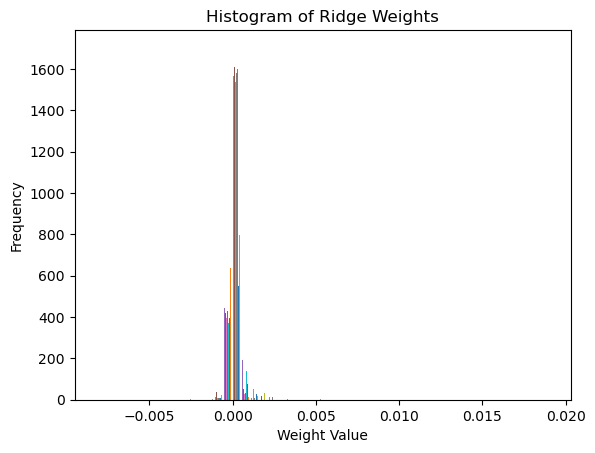

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(w_ridge[4000:6000,4000:6000].cpu().numpy(), bins=50)
plt.title('Histogram of Ridge Weights')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.show()  

In [20]:
torch.max(w_ridge), torch.min(w_ridge)

(tensor(0.0517), tensor(-0.0175))

In [18]:
# define the rank
rank = 5

w_ridge_low_rank = w_ridge @ V[:rank,:].T @ V[:rank,:]

In [19]:
# Evaluate the model on test data
y_pred = torch.from_numpy(x_test) @ w_ridge
y_pred_low_rank = torch.from_numpy(x_test) @ w_ridge_low_rank

# compute the yearly average
y_pred_yearly = y_pred.reshape(y_pred.shape[0], y_pred.shape[1] // 12, 12, y_pred.shape[2])
y_pred_yearly = y_pred_yearly.nanmean(axis=2)

y_pred_low_rank_yearly = y_pred_low_rank.reshape(y_pred_low_rank.shape[0], y_pred_low_rank.shape[1] // 12, 12, y_pred_low_rank.shape[2])
y_pred_low_rank_yearly = y_pred_low_rank_yearly.nanmean(axis=2)

# Compute the mean squared error
rmse = torch.sqrt(torch.mean((y_pred_yearly - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank = torch.sqrt(torch.mean((y_pred_low_rank_yearly - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

print(f'  MSE: {rmse}')
print(f'  MSE low-rank: {rmse_low_rank}')

  MSE: [0.2082471  0.43262067 0.20838569 0.25053522 0.24116229]
  MSE low-rank: [0.20918338 0.43839192 0.22046031 0.24984083 0.24068755]


/tmp/ipykernel_2402/4123958567.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse = torch.sqrt(torch.mean((y_pred_yearly - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
/tmp/ipykernel_2402/4123958567.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse_low_rank = torch.sqrt(torch.mean((y_pred_low_rank_yearly - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()


In [20]:
import torch.nn.functional as F

def moving_average_smoothing(x, window_size=5, mode='same'):
    """
    Apply moving average smoothing to multivariate time series using PyTorch.
    
    Args:
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
           where first dimension is number of samples, second is time, third is features
        window_size: int, size of the moving average window
        mode: str, padding mode - 'same' keeps original length, 'valid' reduces length
    
    Returns:
        smoothed_x: torch.Tensor of same shape as input (if mode='same') or reduced size
    """
    n_samples, n_timesteps, n_features = x.shape
    
    # Create uniform kernel for moving average
    kernel = torch.ones(1, 1, window_size) / window_size
    
    # Reshape input for conv1d: (batch_size * n_features, 1, n_timesteps)
    x_reshaped = x.permute(0, 2, 1).reshape(n_samples * n_features, 1, n_timesteps)
    
    # Apply padding if mode is 'same'
    if mode == 'same':
        padding = window_size // 2
        x_padded = F.pad(x_reshaped, (padding, padding), mode='reflect')
        smoothed = F.conv1d(x_padded, kernel)
        
        # Ensure output has the same length as input by trimming if necessary
        if smoothed.shape[-1] > n_timesteps:
            # Trim the extra timestep(s) from the end
            smoothed = smoothed[:, :, :n_timesteps]
        elif smoothed.shape[-1] < n_timesteps:
            # This shouldn't happen with proper padding, but handle it just in case
            padding_needed = n_timesteps - smoothed.shape[-1]
            smoothed = F.pad(smoothed, (0, padding_needed), mode='replicate')
            
    else:  # mode == 'valid'
        smoothed = F.conv1d(x_reshaped, kernel)
    
    # Reshape back to original format
    if mode == 'same':
        smoothed = smoothed.reshape(n_samples, n_features, n_timesteps).permute(0, 2, 1)
    else:
        new_timesteps = smoothed.shape[-1]
        smoothed = smoothed.reshape(n_samples, n_features, new_timesteps).permute(0, 2, 1)
    
    return smoothed

# Apply different smoothing methods
window_size = 20

# Moving average smoothing
x_test_ma = moving_average_smoothing(torch.from_numpy(x_test), window_size=12*window_size, mode='same')
print(f"Moving average smoothed shape: {x_test_ma.shape}")

Moving average smoothed shape: torch.Size([5, 876, 10368])


# Learn weighted ridge regression

In [21]:
from evaluation import compute_trends_from_data
# learn a ridge regression for each climate model

# Compute trends for all predictions
trend_years = slice(30, None)  # Last 43 years for trend computation

# w_ridge_per_model = {}
# w_ridge_low_rank_per_model = {}

# rmse_per_model = {}
# rmse_per_model_ma = {}
# rmse_low_rank_per_model = {}
# rmse_low_rank_per_model_ma = {}

# for dir in list(data_anomaly_yearly.keys()):
#     print(f'Computing ridge regression for {dir}')

#     # merge the corrupted data  and the original data for this specific model 
#     x_train_yearly_tmp = data_anomaly_yearly[dir].view(data_anomaly_yearly[dir].shape[0]*data_anomaly_yearly[dir].shape[1],data_anomaly_yearly[dir].shape[2])
#     y_train_yearly_tmp = data_forced_response_yearly[dir].view(data_anomaly_yearly[dir].shape[0]*data_anomaly_yearly[dir].shape[1],data_anomaly_yearly[dir].shape[2])


#     w_ridge_per_model[dir] = ridge_regression(x_train_yearly_tmp, y_train_yearly_tmp, lambda_reg= lambda_tmp, verbose=True)
    
#     # low rank regression
#     x_train_yearly_tmp_cat = torch.cat([x_train_yearly_tmp, torch.sqrt(torch.tensor(lambda_tmp))*torch.eye(x_train_yearly_tmp.shape[1])], dim=0)
#     U,S,V = torch.linalg.svd(x_train_yearly_tmp_cat@w_ridge_per_model[dir],full_matrices=False)

#     # # define the rank
#     rank = 10

#     w_ridge_low_rank_per_model[dir] = w_ridge_per_model[dir] @ V[:rank,:].T@V[:rank,:]

#     # Evaluate the model on test data
#     y_pred_tmp = torch.from_numpy(x_test) @ w_ridge_per_model[dir]
#     y_pred_tmp_ma = x_test_ma @ w_ridge_per_model[dir]
#     y_pred_low_rank_tmp= torch.from_numpy(x_test) @ w_ridge_low_rank_per_model[dir]
#     y_pred_low_rank_tmp_ma = x_test_ma @ w_ridge_low_rank_per_model[dir]

#     # compute yearly average
#     # print(y_pred_tmp.shape)
#     y_pred_tmp_yearly = y_pred_tmp.reshape(y_pred_tmp.shape[0], y_pred_tmp.shape[1] // 12, 12, y_pred_tmp.shape[2])
#     y_pred_tmp_yearly = y_pred_tmp_yearly.nanmean(axis=2)

#     y_pred_tmp_ma_yearly = y_pred_tmp_ma.reshape(y_pred_tmp_ma.shape[0], y_pred_tmp_ma.shape[1] // 12, 12, y_pred_tmp_ma.shape[2])
#     y_pred_tmp_ma_yearly = y_pred_tmp_ma_yearly.nanmean(axis=2)

#     y_pred_low_rank_tmp_yearly = y_pred_low_rank_tmp.reshape(y_pred_low_rank_tmp.shape[0], y_pred_low_rank_tmp.shape[1] // 12, 12, y_pred_low_rank_tmp.shape[2])
#     y_pred_low_rank_tmp_yearly = y_pred_low_rank_tmp_yearly.nanmean(axis=2)

#     y_pred_low_rank_tmp_ma_yearly = y_pred_low_rank_tmp_ma.reshape(y_pred_low_rank_tmp_ma.shape[0], y_pred_low_rank_tmp_ma.shape[1] // 12, 12, y_pred_low_rank_tmp_ma.shape[2])
#     y_pred_low_rank_tmp_ma_yearly = y_pred_low_rank_tmp_ma_yearly.nanmean(axis=2)

#     # compute trend
#     trends_ridge = compute_trends_from_data(y_pred_tmp_yearly, trend_years)
#     trends_ridge_low_rank = compute_trends_from_data(y_pred_low_rank_tmp_yearly, trend_years)
#     trends_ridge_ma = compute_trends_from_data(y_pred_tmp_ma_yearly, trend_years)
#     trends_ridge_low_rank_ma = compute_trends_from_data(y_pred_low_rank_tmp_ma_yearly, trend_years)
#     trends_groundtruth = compute_trends_from_data(y_test_yearly, trend_years)

#     # Compute the mean squared error
#     rmse_per_model[dir] = np.sqrt(np.nanmean((trends_ridge - trends_groundtruth) ** 2,axis=1))
#     rmse_per_model_ma[dir] = np.sqrt(np.nanmean((trends_ridge_ma - trends_groundtruth) ** 2,axis=1))
#     rmse_low_rank_per_model[dir] = np.sqrt(np.nanmean((trends_ridge_low_rank - trends_groundtruth) ** 2,axis=1))
#     rmse_low_rank_per_model_ma[dir] = np.sqrt(np.nanmean((trends_ridge_low_rank_ma - trends_groundtruth) ** 2,axis=1))

#     print(f'  MSE : {rmse_per_model[dir]}')
#     print(f'  MSE moving average: {rmse_per_model_ma[dir]}')
#     print(f'  MSE low-rank: {rmse_low_rank_per_model[dir]}')
#     print(f'  MSE low-rank moving average: {rmse_low_rank_per_model_ma[dir]}')
    

In [22]:
# compute the weight for the weighted prediction
weights = np.zeros((x_test.shape[0], x_test.shape[1], len(data_anomaly_yearly.keys())))
for i in range(x_test.shape[0]):
    for idx_m, m in enumerate(list(data_anomaly_yearly.keys())):
        weights[i, :, idx_m] = rf_model.predict_proba(x_test[i, :, :])[:, idx_m]
        # weights[i, :, idx_m] = 1/len(data_anomaly_yearly.keys())


In [23]:
# compute the weighted prediction
# y_pred_weighted = torch.zeros((x_test.shape[0], x_test.shape[1], x_test.shape[2]))
# for i in range(x_test.shape[0]):
#     for idx_m, m in enumerate(list(data_anomaly_yearly.keys())):
#         print((torch.from_numpy(x_test)[i, :, :] @ w_ridge_per_model[m]).shape)
#         y_pred_weighted[i, :, :] += torch.from_numpy(weights)[i, :, idx_m].unsqueeze(0).to(torch.float32) @ (torch.from_numpy(x_test)[i, :, :] @ w_ridge_per_model[m])

In [24]:
# Evaluate the model on test data with smoothing
y_pred_ma = x_test_ma @ w_ridge
y_pred_low_rank_ma = x_test_ma @ w_ridge_low_rank

# compute the yearly prediction
y_pred_ma_yearly = y_pred_ma.reshape(y_pred_ma.shape[0], y_pred_ma.shape[1] // 12, 12, y_pred_ma.shape[2]).mean(dim=2)
y_pred_low_rank_ma_yearly = y_pred_low_rank_ma.reshape(y_pred_low_rank_ma.shape[0], y_pred_low_rank_ma.shape[1] // 12, 12, y_pred_low_rank_ma.shape[2]).mean(dim=2)

In [26]:
# compute the yearly average of the prediction
# y_pred_weighted_yearly = y_pred_weighted.reshape(y_pred_weighted.shape[0], y_pred_weighted.shape[1] // 12, 12, y_pred_weighted.shape[2]).mean(dim=2)

# compute the trend of the prediction using the weights
# trend_weighted = compute_trends_from_data(y_pred_weighted_yearly, trend_years)
trend_groundtruth = compute_trends_from_data(y_test_yearly, trend_years)
trend_ridge = compute_trends_from_data(y_pred_yearly, trend_years)
trend_ridge_low_rank = compute_trends_from_data(y_pred_low_rank_yearly, trend_years)
trend_ridge_ma = compute_trends_from_data(y_pred_ma_yearly, trend_years)
trend_ridge_low_rank_ma = compute_trends_from_data(y_pred_low_rank_ma_yearly, trend_years)

# compute rmse and compare with ridge solution and low-rank ridge solution
# rmse_weighted = np.sqrt(np.nanmean((trend_weighted - trends_groundtruth) ** 2,axis=1))

# compute rmse for ridge and low-rank ridge solutions
rmse_ridge = np.sqrt(np.nanmean((trend_ridge - trend_groundtruth) ** 2,axis=1))
rmse_ridge_low_rank = np.sqrt(np.nanmean((trend_ridge_low_rank - trend_groundtruth) ** 2,axis=1))

rmse_ridge_ma = np.sqrt(np.nanmean((trend_ridge_ma - trend_groundtruth) ** 2,axis=1))
rmse_ridge_low_rank_ma = np.sqrt(np.nanmean((trend_ridge_low_rank_ma - trend_groundtruth) ** 2,axis=1))

# compare some statistics such as mean, median, 75th percentile, 90th, 95th and worst case
def print_statistics(rmse_array, method_name):
    print(f"Statistics for {method_name}:")
    print(f"  Mean RMSE: {np.mean(rmse_array):.4f}")
    print(f"  Median RMSE: {np.median(rmse_array):.4f}")
    print(f"  75th Percentile RMSE: {np.percentile(rmse_array, 75):.4f}")
    print(f"  90th Percentile RMSE: {np.percentile(rmse_array, 90):.4f}")
    print(f"  95th Percentile RMSE: {np.percentile(rmse_array, 95):.4f}")
    print(f"  Worst Case RMSE: {np.max(rmse_array):.4f}")
    print("")

# print_statistics(rmse_weighted, "Weighted Ridge Regression")
print_statistics(rmse_ridge, "Ridge Regression")
print_statistics(rmse_ridge_low_rank, "Ridge Regression Low Rank")
print_statistics(rmse_ridge_ma, "Ridge Regression with smoothing")
print_statistics(rmse_ridge_low_rank_ma, "Ridge Regression Low Rank with smoothing")


Statistics for Ridge Regression:
  Mean RMSE: 0.0110
  Median RMSE: 0.0105
  75th Percentile RMSE: 0.0115
  90th Percentile RMSE: 0.0141
  95th Percentile RMSE: 0.0149
  Worst Case RMSE: 0.0158

Statistics for Ridge Regression Low Rank:
  Mean RMSE: 0.0117
  Median RMSE: 0.0118
  75th Percentile RMSE: 0.0120
  90th Percentile RMSE: 0.0149
  95th Percentile RMSE: 0.0158
  Worst Case RMSE: 0.0168

Statistics for Ridge Regression with smoothing:
  Mean RMSE: 0.0107
  Median RMSE: 0.0116
  75th Percentile RMSE: 0.0122
  90th Percentile RMSE: 0.0129
  95th Percentile RMSE: 0.0131
  Worst Case RMSE: 0.0134

Statistics for Ridge Regression Low Rank with smoothing:
  Mean RMSE: 0.0114
  Median RMSE: 0.0123
  75th Percentile RMSE: 0.0128
  90th Percentile RMSE: 0.0138
  95th Percentile RMSE: 0.0142
  Worst Case RMSE: 0.0145



In [ ]:
# compare with the trend of the estimates
trend_estimates_yearly = np.zeros((data_estimates_yearly.shape[0], data_estimates_yearly.shape[1], data_estimates_yearly.shape[3]))


for idx_r in range(data_estimates_yearly.shape[0]):
    trend_estimates_yearly[idx_r,:,:] = compute_trends_from_data(data_estimates_yearly[idx_r,:,:,:],trend_years)
    print(f'  Trend estimates: {trend_estimates_yearly[idx_r,:,:].shape}')

  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)
  Trend estimates: (5, 10368)


In [ ]:
rmse_ridge = np.zeros((y_test_yearly.shape[0]))

for idx_r in range(y_test_yearly.shape[0]):
    rmse_ridge[idx_r] = np.sqrt(np.mean((trend_ridge_ma[idx_r,:] - trends_groundtruth[idx_r,:]) ** 2))


# compute the rmse of the trend estimates
rmse_trend_estimates = np.zeros((trend_estimates_yearly.shape[0], trend_estimates_yearly.shape[1]))

for idx_r in range(trend_estimates_yearly.shape[0]):
    rmse_trend_estimates[idx_r,:] = np.sqrt(np.mean((trend_estimates_yearly[idx_r,:,:] - trends_groundtruth) ** 2,axis=1))
    print(f'  RMSE trend estimates: {rmse_trend_estimates[idx_r,:]}')



  RMSE trend estimates: [0.0118189  0.02898223 0.00712635 0.01347188 0.01440823]
  RMSE trend estimates: [0.0103457  0.02184277 0.00984254 0.01267572 0.01378576]
  RMSE trend estimates: [0.01151816 0.02748456 0.00659173 0.0136309  0.01466552]
  RMSE trend estimates: [0.01069397 0.01378076 0.01723815 0.01085607 0.01327972]
  RMSE trend estimates: [0.01235991 0.02118625 0.00987315 0.00982071 0.01120206]
  RMSE trend estimates: [0.00957724 0.01264231 0.01409908 0.01361773 0.01333229]
  RMSE trend estimates: [0.01097688 0.0327203  0.00862228 0.01200074 0.01313599]
  RMSE trend estimates: [0.01490034 0.02391218 0.01342923 0.01595471 0.02219148]
  RMSE trend estimates: [0.01055612 0.01488573 0.01002347 0.00998429 0.0109439 ]
  RMSE trend estimates: [0.00840158 0.01944294 0.00936992 0.01295477 0.01242766]
  RMSE trend estimates: [0.0116702  0.02676051 0.00696981 0.01376076 0.01465621]
  RMSE trend estimates: [0.01311168 0.03019076 0.0062869  0.01278284 0.0127349 ]
  RMSE trend estimates: [0.0

In [ ]:

print_statistics(rmse_ridge, "Ridge Regression")

for i in range(rmse_trend_estimates.shape[0]):
    print_statistics(rmse_trend_estimates[i], f"Trend Estimates Method {i}")


Statistics for Ridge Regression:
  Mean RMSE: 0.0107
  Median RMSE: 0.0111
  75th Percentile RMSE: 0.0119
  90th Percentile RMSE: 0.0133
  95th Percentile RMSE: 0.0137
  Worst Case RMSE: 0.0142

Statistics for Trend Estimates Method 0:
  Mean RMSE: 0.0152
  Median RMSE: 0.0135
  75th Percentile RMSE: 0.0144
  90th Percentile RMSE: 0.0232
  95th Percentile RMSE: 0.0261
  Worst Case RMSE: 0.0290

Statistics for Trend Estimates Method 1:
  Mean RMSE: 0.0137
  Median RMSE: 0.0127
  75th Percentile RMSE: 0.0138
  90th Percentile RMSE: 0.0186
  95th Percentile RMSE: 0.0202
  Worst Case RMSE: 0.0218

Statistics for Trend Estimates Method 2:
  Mean RMSE: 0.0148
  Median RMSE: 0.0136
  75th Percentile RMSE: 0.0147
  90th Percentile RMSE: 0.0224
  95th Percentile RMSE: 0.0249
  Worst Case RMSE: 0.0275

Statistics for Trend Estimates Method 3:
  Mean RMSE: 0.0132
  Median RMSE: 0.0133
  75th Percentile RMSE: 0.0138
  90th Percentile RMSE: 0.0159
  95th Percentile RMSE: 0.0165
  Worst Case RMSE: 0

In [ ]:
# Train the robust model with autograd
def robust_ridge_regression(x, y, d, lambda_=1.0, mu_=1.0, verbose=False, dtype=torch.float32):
    """
    Robust ridge regression with low-rank approximation.
    
    Args:
        x: input data (torch.Tensor)
        y: target data (torch.Tensor)
        lambda_: regularization parameter (float)
        rank: rank for low-rank approximation (int)
        verbose: if True, print additional information (bool)
        dtype: data type for the tensors (torch.dtype)
        
    Returns:
        w: weights of the model (torch.Tensor)
    """
    w = torch.zeros((d, d), dtype=dtype).requires_grad_(True)

    optimizer = torch.optim.SGD([w], lr=1e-4)

    loss_tmp = torch.zeros(len(x.keys()), dtype=dtype)

    for epoch in range(10):
        optimizer.zero_grad()
        
        for idx_m,m in enumerate(list(x.keys())):
            x_m = x[m].to(dtype)
            y_m = y[m].to(dtype)

            # Compute the prediction
            y_pred = x_m @ w
            
            # Compute the loss
            loss_tmp[idx_m] = (1/mu_)*torch.nanmean((y_pred - y_m) ** 2)


        loss = mu_*torch.logsumexp(loss_tmp, dim=0) + lambda_ * torch.norm(w, p='fro')**2

        # Backpropagation
        loss.backward(retain_graph=True)
        
        # Update weights
        optimizer.step()

        print(f'Epoch {epoch}, Loss: {loss.item()}')
        
        # if verbose and epoch % 100 == 0:
        #     print(f'Epoch {epoch}, Loss: {loss.item()}')            

    if verbose:
        print(f'  Weights shape: {w.shape}')
    
    return w

: 

In [ ]:
# d = longitude.shape[0] * latitude.shape[0]  # Assuming longitude is a 2D grid, flatten it to a 1D vector
# w = robust_ridge_regression(data_anomaly_yearly, data_forced_response_yearly, d, lambda_=100.0, mu_=100.0, verbose=False, dtype=torch.float32)

: 

In [ ]:
# # Evaluate the model on test data
# y_pred_robust = x_test_yearly @ w

# # Compute the mean squared error
# rmse_linreg = torch.sqrt(torch.mean((y_pred_robust - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

# print(f'  MSE: {rmse_linreg}')

: 

# Idea 1: Linear regression per grid cell

In [ ]:
def linear_regression_per_grid_cell(x,y,lambda_=0.0):
    """Perform linear regression for each grid cell and return the coefficients.
       Args:
           x: numpy array of shape (runs, time steps, latitude x longitude)
           y: numpy array of shape (runs, time steps, latitude x longitude)
       Return:
           w: numpy array of shape (latitude x longitude, runs*time steps)
    """

    # Compute the coefficients for each grid cell
    # w = np.linalg.lstsq(x, y, rcond=None)[0]
    w = torch.sum(x * y, axis=0) / (torch.sum(x ** 2, axis=0)+lambda_)
    
    return w

: 

# Idea 2: Smoothing of temporal time series

In [ ]:
import torch.nn.functional as F

def moving_average_smoothing(x, window_size=5, mode='same'):
    """
    Apply moving average smoothing to multivariate time series using PyTorch.
    
    Args:
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
           where first dimension is number of samples, second is time, third is features
        window_size: int, size of the moving average window
        mode: str, padding mode - 'same' keeps original length, 'valid' reduces length
    
    Returns:
        smoothed_x: torch.Tensor of same shape as input (if mode='same') or reduced size
    """
    n_samples, n_timesteps, n_features = x.shape
    
    # Create uniform kernel for moving average
    kernel = torch.ones(1, 1, window_size) / window_size
    
    # Reshape input for conv1d: (batch_size * n_features, 1, n_timesteps)
    x_reshaped = x.permute(0, 2, 1).reshape(n_samples * n_features, 1, n_timesteps)
    
    # Apply padding if mode is 'same'
    if mode == 'same':
        padding = window_size // 2
        x_padded = F.pad(x_reshaped, (padding, padding), mode='reflect')
        smoothed = F.conv1d(x_padded, kernel)
        
        # Ensure output has the same length as input by trimming if necessary
        if smoothed.shape[-1] > n_timesteps:
            # Trim the extra timestep(s) from the end
            smoothed = smoothed[:, :, :n_timesteps]
        elif smoothed.shape[-1] < n_timesteps:
            # This shouldn't happen with proper padding, but handle it just in case
            padding_needed = n_timesteps - smoothed.shape[-1]
            smoothed = F.pad(smoothed, (0, padding_needed), mode='replicate')
            
    else:  # mode == 'valid'
        smoothed = F.conv1d(x_reshaped, kernel)
    
    # Reshape back to original format
    if mode == 'same':
        smoothed = smoothed.reshape(n_samples, n_features, n_timesteps).permute(0, 2, 1)
    else:
        new_timesteps = smoothed.shape[-1]
        smoothed = smoothed.reshape(n_samples, n_features, new_timesteps).permute(0, 2, 1)
    
    return smoothed

# Apply different smoothing methods
window_size = 15

# Moving average smoothing
x_test_ma = moving_average_smoothing(torch.from_numpy(x_test), window_size=12*window_size, mode='same')
print(f"Moving average smoothed shape: {x_test_ma.shape}")

x_test_ma_yearly = x_test_ma.reshape(x_test_ma.shape[0], x_test_ma.shape[1] // 12, 12, x_test_ma.shape[2])
x_test_ma_yearly = x_test_ma_yearly.nanmean(axis=2)

Moving average smoothed shape: torch.Size([10, 876, 10368])


: 

: 

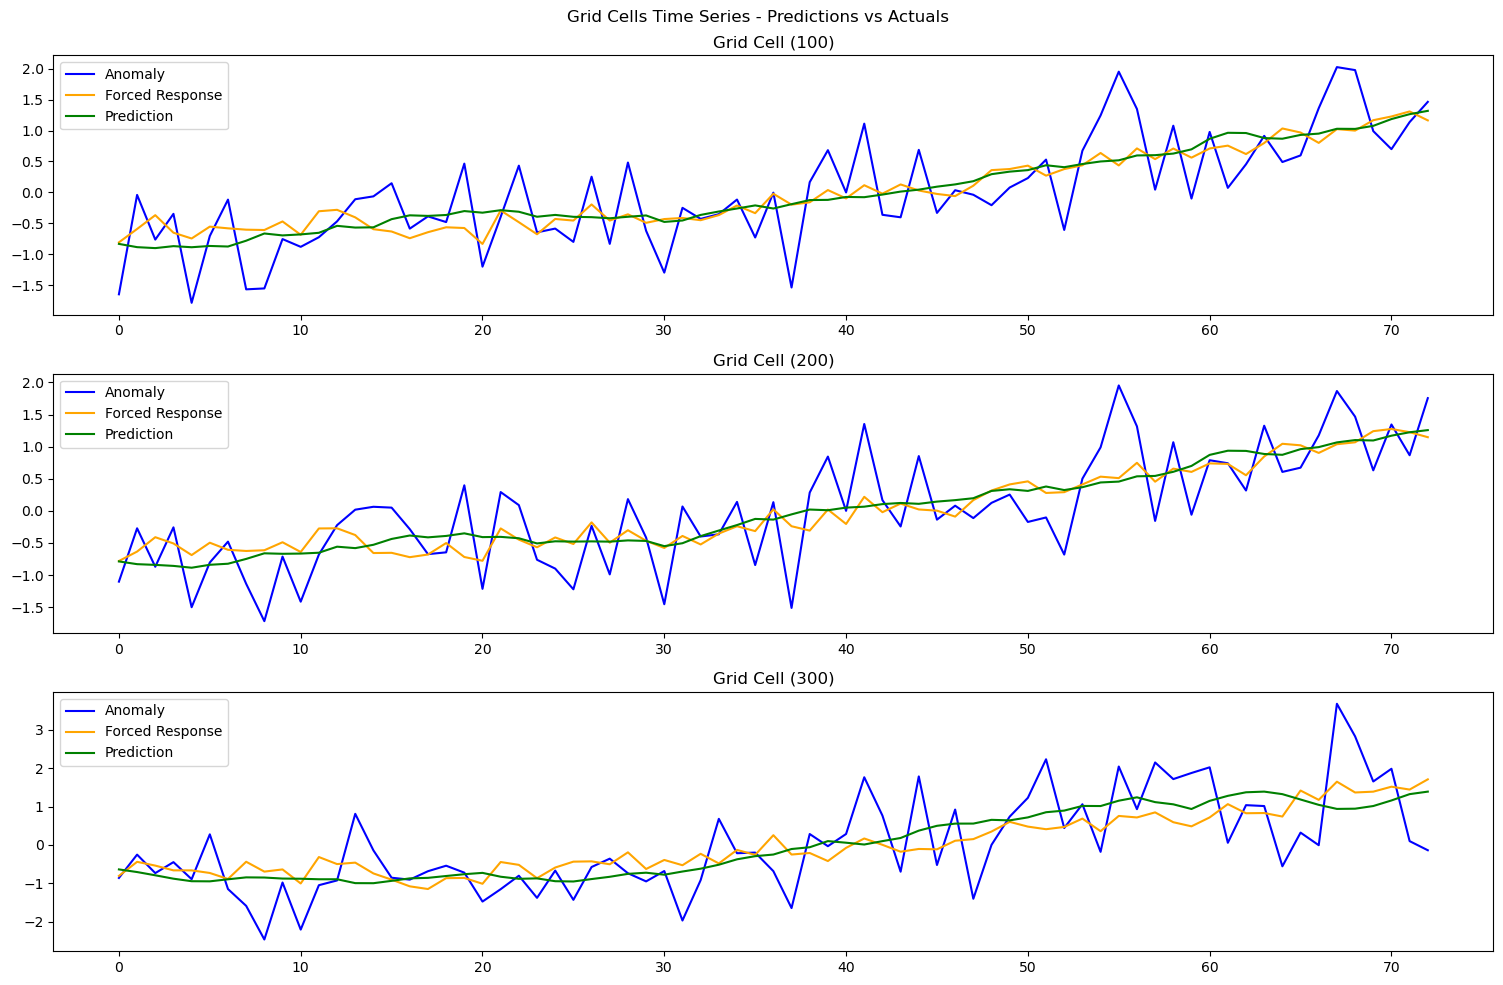

: 

In [ ]:
# plot some grid cells time series of the predictions, the input and the target forced response
import matplotlib.pyplot as plt

def plot_grid_cells_time_series(x, y, y_pred, grid_cells,idx_run, title='Grid Cells Time Series'):
    """
    Plot time series for specified grid cells.
    
    Args:
        x: Input data (anomaly)
        y: Target data (forced response)
        y_pred: Predicted data
        grid_cells: List of tuples (lat_idx, lon_idx) for grid cells to plot
        title: Title of the plot
    """
    plt.figure(figsize=(15, 10))
    
    for grid_idx in grid_cells:
        plt.subplot(len(grid_cells), 1, grid_cells.index(grid_idx) + 1)
        plt.plot(x[idx_run,:, grid_idx], label='Anomaly', color='blue')
        plt.plot(y[idx_run,:, grid_idx], label='Forced Response', color='orange')
        plt.plot(y_pred[idx_run,:, grid_idx], label='Prediction', color='green')
        plt.title(f'Grid Cell ({grid_idx})')
        plt.legend()
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Example grid cells to plot (latitude index, longitude index)
grid_cells_to_plot = [100,200,300]  # Adjust indices based on your data shape
idx_run = 2
plot_grid_cells_time_series(x_test_yearly, y_test_yearly, x_test_ma_yearly, grid_cells_to_plot, idx_run, title='Grid Cells Time Series - Predictions vs Actuals')

In [ ]:
# Evaluate the model on the smoothed data
y_pred_ma = x_test_ma @ w_ridge
y_pred_low_rank_ma = x_test_ma @ w_ridge_low_rank

# compute yearly average of prediction
y_pred_ma_yearly = y_pred_ma.reshape(y_pred_ma.shape[0], y_pred_ma.shape[1] // 12, 12, y_pred_ma.shape[2])
y_pred_ma_yearly = y_pred_ma_yearly.nanmean(axis=2)

y_pred_low_rank_ma_yearly = y_pred_low_rank_ma.reshape(y_pred_low_rank_ma.shape[0], y_pred_low_rank_ma.shape[1] // 12, 12, y_pred_low_rank_ma.shape[2]) 
y_pred_low_rank_ma_yearly = y_pred_low_rank_ma_yearly.nanmean(axis=2)

# Compute the mean squared error
rmse_ma = torch.sqrt(torch.mean((y_pred_ma_yearly - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank_ma = torch.sqrt(torch.mean((y_pred_low_rank_ma_yearly - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

print(f'  MSE: {rmse}')
print(f'  MSE trace norm: {rmse_low_rank}')

print(f'  MSE ma: {rmse_ma}')
print(f'  MSE trace norm ma: {rmse_low_rank_ma}')

  MSE: [0.18189248 0.2082471  0.259286   0.43262067 0.20838569 0.17132851
 0.25053522 0.16150728 0.51938856 0.24116229]
  MSE trace norm: [0.18527216 0.20918338 0.27334    0.43839192 0.22046031 0.18845452
 0.24984083 0.16975498 0.51644605 0.24068755]
  MSE ma: [0.15681194 0.17976257 0.26184705 0.4089889  0.20305009 0.15177132
 0.20525879 0.14329435 0.48649094 0.22508459]
  MSE trace norm ma: [0.1626483  0.18521735 0.27595395 0.41617298 0.21573961 0.17113695
 0.20725083 0.15468763 0.4854178  0.22732237]


/tmp/ipykernel_40599/2718829049.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse_ma = torch.sqrt(torch.mean((y_pred_ma_yearly - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
/tmp/ipykernel_40599/2718829049.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse_low_rank_ma = torch.sqrt(torch.mean((y_pred_low_rank_ma_yearly - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()


: 

# Idea 3: Learn M denoising models and provide a combination of all predictions

In [ ]:
from evaluation import compute_trends_from_data

def to_yearly_and_trends(pred_data, trend_years=slice(30, None)):
    """Helper function to convert monthly to yearly and compute trends."""
    pred_numpy = pred_data.cpu().numpy() if isinstance(pred_data, torch.Tensor) else pred_data
    pred_yearly = pred_numpy.reshape(pred_numpy.shape[0], pred_numpy.shape[1] // 12, 12, pred_numpy.shape[2])
    pred_yearly = pred_yearly.mean(axis=2)
    return compute_trends_from_data(pred_yearly, trend_years)


: 

In [ ]:
# # learn a ridge regression for each climate model

# # Compute trends for all predictions
# trend_years = slice(30, None)  # Last 43 years for trend computation

# w_ridge_per_model = {}
# w_ridge_low_rank_per_model = {}

# rmse_per_model = {}
# rmse_per_model_ma = {}
# rmse_low_rank_per_model = {}
# rmse_low_rank_per_model_ma = {}

# for dir in list(data_anomaly_yearly.keys()):
#     print(f'Computing ridge regression for {dir}')

#     # merge the corrupted data  and the original data for this specific model 
#     x_train_yearly_tmp = data_anomaly_yearly[dir].view(data_anomaly_yearly[dir].shape[0]*data_anomaly_yearly[dir].shape[1],data_anomaly_yearly[dir].shape[2])
#     y_train_yearly_tmp = data_forced_response_yearly[dir].view(data_anomaly_yearly[dir].shape[0]*data_anomaly_yearly[dir].shape[1],data_anomaly_yearly[dir].shape[2])


#     w_ridge_per_model[dir] = ridge_regression(x_train_yearly_tmp, y_train_yearly_tmp, lambda_reg= lambda_tmp, verbose=True)
    
#     # low rank regression
#     x_train_yearly_tmp_cat = torch.cat([x_train_yearly_tmp, torch.sqrt(torch.tensor(lambda_tmp))*torch.eye(x_train_yearly_tmp.shape[1])], dim=0)
#     U,S,V = torch.linalg.svd(x_train_yearly_tmp_cat@w_ridge_per_model[dir],full_matrices=False)

#     # # define the rank
#     rank = 10

#     w_ridge_low_rank_per_model[dir] = w_ridge_per_model[dir] @ V[:rank,:].T@V[:rank,:]

#     # Evaluate the model on test data
#     y_pred_tmp = torch.from_numpy(x_test) @ w_ridge_per_model[dir]
#     y_pred_tmp_ma = x_test_ma @ w_ridge_per_model[dir]
#     y_pred_low_rank_tmp= torch.from_numpy(x_test) @ w_ridge_low_rank_per_model[dir]
#     y_pred_low_rank_tmp_ma = x_test_ma @ w_ridge_low_rank_per_model[dir]

#     # compute yearly average
#     # print(y_pred_tmp.shape)
#     # y_pred_tmp_yearly = y_pred_tmp.reshape(y_pred_tmp.shape[0], y_pred_tmp.shape[1] // 12, 12, y_pred_tmp.shape[2])
#     # y_pred_tmp_yearly = y_pred_tmp_yearly.nanmean(axis=2)

#     # y_pred_tmp_ma_yearly = y_pred_tmp_ma.reshape(y_pred_tmp_ma.shape[0], y_pred_tmp_ma.shape[1] // 12, 12, y_pred_tmp_ma.shape[2])
#     # y_pred_tmp_ma_yearly = y_pred_tmp_ma_yearly.nanmean(axis=2)

#     # y_pred_low_rank_tmp_yearly = y_pred_low_rank_tmp.reshape(y_pred_low_rank_tmp.shape[0], y_pred_low_rank_tmp.shape[1] // 12, 12, y_pred_low_rank_tmp.shape[2])
#     # y_pred_low_rank_tmp_yearly = y_pred_low_rank_tmp_yearly.nanmean(axis=2)

#     # y_pred_low_rank_tmp_ma_yearly = y_pred_low_rank_tmp_ma.reshape(y_pred_low_rank_tmp_ma.shape[0], y_pred_low_rank_tmp_ma.shape[1] // 12, 12, y_pred_low_rank_tmp_ma.shape[2])
#     # y_pred_low_rank_tmp_ma_yearly = y_pred_low_rank_tmp_ma_yearly.nanmean(axis=2)

#     # compute trend
#     trends_ridge = to_yearly_and_trends(y_pred_tmp, trend_years)
#     trends_ridge_low_rank = to_yearly_and_trends(y_pred_low_rank_tmp, trend_years)
#     trends_ridge_ma = to_yearly_and_trends(y_pred_tmp_ma, trend_years)
#     trends_ridge_low_rank_ma = to_yearly_and_trends(y_pred_low_rank_tmp_ma, trend_years)
#     trends_groundtruth = to_yearly_and_trends(y_test, trend_years)

#     # Compute the mean squared error
#     rmse_per_model[dir] = np.sqrt(np.nanmean((trends_ridge - trends_groundtruth) ** 2,axis=1))
#     rmse_per_model_ma[dir] = np.sqrt(np.nanmean((trends_ridge_ma - trends_groundtruth) ** 2,axis=1))
#     rmse_low_rank_per_model[dir] = np.sqrt(np.nanmean((trends_ridge_low_rank - trends_groundtruth) ** 2,axis=1))
#     rmse_low_rank_per_model_ma[dir] = np.sqrt(np.nanmean((trends_ridge_low_rank_ma - trends_groundtruth) ** 2,axis=1))

#     print(f'  MSE : {rmse_per_model[dir]}')
#     print(f'  MSE moving average: {rmse_per_model_ma[dir]}')
#     print(f'  MSE low-rank: {rmse_low_rank_per_model[dir]}')
#     print(f'  MSE low-rank moving average: {rmse_low_rank_per_model_ma[dir]}')

Computing ridge regression for CESM2
Solving ridge regression with λ=2500.0
Input shape: X=torch.Size([11050, 10368]), Y=torch.Size([11050, 10368])
Reshaped: X=torch.Size([11050, 10368]), Y=torch.Size([11050, 10368])
Ridge weights computed: torch.Size([10368, 10368])


  MSE : [0.01056771 0.0131814  0.03848352 0.01598225 0.01824343 0.00203295
 0.01784851 0.01372339 0.02154118 0.01341458]
  MSE moving average: [0.01079219 0.01385223 0.03888401 0.01607512 0.01883982 0.00296305
 0.01819894 0.01417648 0.0217482  0.01348953]
  MSE low-rank: [0.01062986 0.01328719 0.03857579 0.01617153 0.01833136 0.0020596
 0.01787434 0.01378914 0.02153408 0.01346855]
  MSE low-rank moving average: [0.01084868 0.01396151 0.03897841 0.01625682 0.01892787 0.00297819
 0.01822909 0.01424102 0.02174211 0.01354331]
Computing ridge regression for CanESM5
Solving ridge regression with λ=2500.0
Input shape: X=torch.Size([5525, 10368]), Y=torch.Size([5525, 10368])
Reshaped: X=torch.Size([5525, 10368]), Y=torch.Size([5525, 10368])
Ridge weights computed: torch.Size([10368, 10368])
  MSE : [0.00823263 0.00919259 0.00744575 0.01939415 0.01270055 0.00800274
 0.00873088 0.00854708 0.03019893 0.01222922]
  MSE moving average: [0.00863552 0.00893946 0.00973782 0.01788363 0.0128416  0.00782

: 

In [ ]:
def combined_loo_ridge(x, y, w, verbose=False, dtype=torch.float32):
    """
    Robust ridge regression with low-rank approximation.

    Args:
        x: input data (torch.Tensor)
        y: target data (torch.Tensor)
        w: weight matrix per model (dict of Tensors)
        verbose: if True, print additional information (bool)
        dtype: data type for the tensors (torch.dtype)
    Returns:
        alpha: weights of the model (torch.Tensor)
    """
    alpha = torch.ones(len(x.keys()), dtype=dtype, requires_grad=True)
    alpha.data /= torch.sum(alpha.data)

    optimizer = torch.optim.Adam([alpha], lr=1e-2)

    for epoch in range(10):
        optimizer.zero_grad()
        loss = 0.0  # accumulate as a Python float

        for idx_m, m in enumerate(list(x.keys())):
            x_m = x[m].to(dtype)
            y_m = y[m].to(dtype)

            # compute the weighted sum
            w_m = torch.einsum('n,nmk->mk', alpha, w) - alpha[idx_m] * w[idx_m,:,:]
            y_pred = x_m @ w_m

            # Compute the loss for this model and accumulate
            loss = loss + torch.nanmean((y_pred - y_m) ** 2)

        loss += 10.0*torch.sum(alpha*torch.log(alpha))

        # Now loss is a scalar tensor, so we can backward safely
        loss.backward()
        optimizer.step()

        # Optionally normalize alpha after each step
        # with torch.no_grad():
        #     alpha.data /= torch.sum(alpha.data)

        print(f'Epoch {epoch}, Loss: {loss.item()}')

    if verbose:
        print(f'  Weights shape: {alpha.shape}')

    return alpha

: 

In [ ]:
w_ridge_per_model_tmp = torch.zeros((len(w_ridge_per_model), w_ridge_per_model[list(w_ridge_per_model.keys())[0]].shape[0], w_ridge_per_model[list(w_ridge_per_model.keys())[0]].shape[1]), dtype=torch.float32)
for idx_m, m in enumerate(list(w_ridge_per_model.keys())):
    w_ridge_per_model_tmp[idx_m,:,:] = w_ridge_per_model[m]

: 

In [ ]:
alpha = combined_loo_ridge(data_anomaly_yearly, data_forced_response_yearly, w_ridge_per_model_tmp, verbose=False, dtype=torch.float32)

Epoch 0, Loss: -12.952984809875488
Epoch 1, Loss: -13.693483352661133
Epoch 2, Loss: -14.348464965820312


Epoch 3, Loss: -14.918095588684082
Epoch 4, Loss: -15.403285026550293
Epoch 5, Loss: -15.80588436126709
Epoch 6, Loss: -16.128877639770508
Epoch 7, Loss: -16.37656021118164
Epoch 8, Loss: -16.5546817779541
Epoch 9, Loss: -16.67051124572754


: 

In [ ]:
alpha/torch.sum(alpha)

tensor([0.2005, 0.2002, 0.1997, 0.1993, 0.2003], grad_fn=<DivBackward0>)

: 

In [ ]:
# Given the M denoising models, one can compute a convex combination of the predictions 
# based on the distance to the training data of the climate model m.

def distance_to_training_data(x, y, w):
    """
    Compute the distance of the predictions to the training data.
    
    Args:
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
        y: torch.Tensor of shape (n_samples, n_timesteps, n_features)
        w: torch.Tensor of shape (n_features, n_outputs)
    
    Returns:
        distances: torch.Tensor of shape (n_samples,)
    """
    y_pred = x @ w
    distances = torch.sqrt(torch.sum((y_pred - y) ** 2, dim=(1, 2)))
    print(f'  distances shape: {distances.shape}')
    return distances

def compute_weights(w,x,y):
    """
    Compute weights based on distances to training data.
    
    Args:
        distances: torch.Tensor of shape (n_samples,)
    
    Returns:
        weights: torch.Tensor of shape (n_samples,)
    """
    distances = {}
    weights = torch.zeros((len(w.keys())), dtype=torch.float32)    
 
    for idx_m, m in enumerate(list(w.keys())):
        distances[m] = torch.mean(distance_to_training_data(x[m],y[m],w[m]))
        weights[idx_m] = 1.0 / (distances[m] + 1e-8)  # Add small value to avoid division by zero

    # Normalize weights across all models
    weights = weights / torch.sum(weights, dim=0, keepdim=True)

    return weights

: 

In [ ]:
# compute weighted prediction
def weighted_prediction(weights, w, x):
    """
    Compute the weighted prediction based on the weights and the model coefficients.
    
    Args:
        weights: torch.Tensor of shape (n_models, n_samples)
        w: dict of model coefficients
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
    Returns:
        y_pred: torch.Tensor of shape (n_samples, n_timesteps, n_features)
    """
    y_pred = torch.zeros((x.shape[0], x.shape[1], x.shape[2]), dtype=torch.float32)
    
    for i in range(x.shape[0]):
        for idx_m, m in enumerate(list(w.keys())):
            y_pred[i,:,:] += weights[i,idx_m] * (x[i,:,:] @ w[m])
    
    return y_pred

: 

In [ ]:
# weights = compute_weights(w_ridge_per_model,data_anomaly_yearly,data_forced_response_yearly)
# weights_low_rank = compute_weights(w_ridge_low_rank_per_model,data_anomaly_yearly,data_forced_response_yearly)

weights = alpha.detach().numpy()



# weights = torch.from_numpy(predicted_proba)
# weights_low_rank = torch.from_numpy(predicted_proba)

# weights = torch.ones((x_test_yearly.shape[0], len(w_ridge_per_model.keys())), dtype=torch.float32) / len(w_ridge_per_model.keys())
# weights_low_rank = torch.ones((x_test_yearly.shape[0], len(w_ridge_low_rank_per_model.keys())), dtype=torch.float32) / len(w_ridge_low_rank_per_model.keys())

# y_pred = weighted_prediction(weights, w_ridge_per_model, x_test_ma)
# y_pred_low_rank = weighted_prediction(weights_low_rank, w_ridge_low_rank_per_model, x_test_ma)

y_pred_weighted = torch.zeros((x_test_yearly.shape[0], x_test_yearly.shape[1], x_test_yearly.shape[2]), dtype=torch.float32)
y_pred_low_rank_weighted = torch.zeros((x_test_yearly.shape[0], x_test_yearly.shape[1], x_test_yearly.shape[2]), dtype=torch.float32)

for idx_m, m in enumerate(w_ridge_low_rank_per_model.keys()):
    print(f'Processing model: {m}')
    for i in range(x_test_yearly.shape[0]):
       
        y_pred_weighted[i, :, :] += weights[i,idx_m ] * (x_test_yearly[i,:, :] @ w_ridge_per_model[m])
        y_pred_low_rank_weighted[i, :, :] += weights[i,idx_m ] * (x_test_yearly[i,:,:] @ w_ridge_low_rank_per_model[m])

# Compute the mean squared error
rmse_weighted = torch.sqrt(torch.mean((y_pred_weighted - y_test_yearly) ** 2, axis=(1, 2))).detach().numpy()
rmse_weighted_low_rank = torch.sqrt(torch.mean((y_pred_low_rank_weighted - y_test_yearly) ** 2, axis=(1, 2))).detach().numpy()


rmse[8] = 0.0
rmse_low_rank[8] = 0.0
rmse_ma[8] = 0.0
rmse_low_rank_ma[8] = 0.0
rmse_weighted[8] = 0.0
rmse_weighted_low_rank[8] = 0.0



print(f'  MSE: {rmse}')
print(f'  MSE trace norm: {rmse_low_rank}')

print(f'  MSE with smoothed test data: {rmse_ma}')
print(f'  MSE low-rank with smoothed test data: {rmse_low_rank_ma}')

print(f'  MSE weighted prediction: {rmse_weighted}')
print(f'  MSE weighted prediction trace norm: {rmse_weighted_low_rank}')

Processing model: CESM2


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

: 

In [ ]:
# print quantiles of the rmse
print(f'  RMSE quantiles: {np.quantile(rmse, [0.25, 0.5, 0.75, 0.9, 0.95, 1.0])}')
print(f'  RMSE low rank quantiles: {np.quantile(rmse_low_rank, [0.25, 0.5, 0.75, 0.9, 0.95, 1.0])}')
print(f'  RMSE smoothed quantiles: {np.quantile(rmse_ma, [0.25, 0.5, 0.75,0.9, 0.95, 1.0])}')
print(f'  RMSE low rank smoothed quantiles: {np.quantile(rmse_low_rank_ma, [0.25, 0.5, 0.75,0.9, 0.95, 1.0])}')
print(f'  RMSE weighted quantiles: {np.quantile(rmse_weighted, [0.25, 0.5, 0.75,0.9, 0.95, 1.0])}')
print(f'  RMSE weighted low rank quantiles: {np.quantile(rmse_weighted_low_rank, [0.25, 0.5, 0.75,0.9, 0.95, 1.0])}')

  RMSE quantiles: [0.16665418 0.20669116 0.24204388 0.26729715 0.33731704 0.40733692]
  RMSE low rank quantiles: [0.1800849  0.21327414 0.24140411 0.28257712 0.34801317 0.41344923]
  RMSE smoothed quantiles: [0.14962887 0.19192809 0.22216867 0.27506173 0.33117676 0.38729179]
  RMSE low rank smoothed quantiles: [0.16355051 0.19597693 0.22677093 0.28977264 0.34236595 0.39495927]
  RMSE weighted quantiles: [0.17277467 0.19482792 0.23605242 0.31294608 0.3164205  0.31989491]
  RMSE weighted low rank quantiles: [0.17497919 0.19637619 0.23773659 0.31554226 0.31953341 0.32352456]


: 

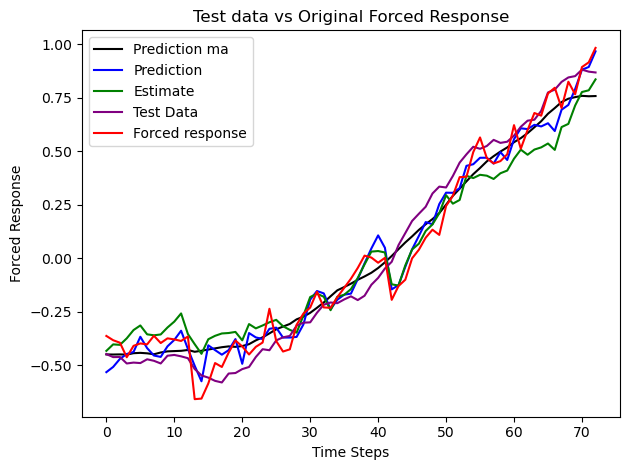

: 

In [ ]:
# plot test data vs the predicted data
import matplotlib.pyplot as plt

idx_cell = 150  # index of the grid cell to plot
idx_run = 2 # index of the run to plot
idx_lon = 30
idx_lat = 30

plt.subplot(1, 1, 1)
plt.plot(y_pred_ma.reshape(y_pred.shape[0], y_pred.shape[1],latitude.shape[0],longitude.shape[0])[idx_run,:,idx_lat,idx_lon], label='Prediction ma', color='black')
plt.plot(y_pred.reshape(y_pred.shape[0], y_pred.shape[1],latitude.shape[0],longitude.shape[0])[idx_run,:,idx_lat,idx_lon], label='Prediction', color='blue')
plt.plot(data_estimates_yearly.reshape(30,y_pred.shape[0], y_pred.shape[1],latitude.shape[0],longitude.shape[0])[5,idx_run,:,idx_lat,idx_lon], label='Estimate', color='green')
plt.plot(x_test_ma.reshape(y_pred.shape[0], y_pred.shape[1],latitude.shape[0],longitude.shape[0])[idx_run,:,idx_lat,idx_lon], label='Test Data', color='purple')
plt.plot(y_test_yearly.reshape(y_pred.shape[0], y_pred.shape[1],latitude.shape[0],longitude.shape[0])[idx_run,:,idx_lat,idx_lon], label='Forced response', color='red')
plt.title('Test data vs Original Forced Response')
plt.xlabel('Time Steps')
plt.ylabel('Forced Response')
plt.legend()


plt.tight_layout()
plt.show()

In [ ]:
# # Weighted prediction using the classifier

# window_size = 3  # Define the size of the sliding window

# # Create sliding windows
# x_windows = np.zeros((x_stacked.shape[0]*(x_stacked.shape[1] - window_size + 1), window_size * x_stacked.shape[2]))
# labels_windows = np.zeros((x_stacked.shape[0]*(x_stacked.shape[1] - window_size + 1),), dtype=np.int64)
# last_idx = 0

# for idx_m, m in enumerate(list(data_anomaly_yearly.keys())):
#     for j in range(data_anomaly_yearly[m].shape[0]):
#         for i in range(x_stacked.shape[1] - window_size + 1):
#             x_windows[last_idx+i,:] = x_stacked[j, i:i + window_size, :].flatten()
#             labels_windows[last_idx+i] = idx_m
#         last_idx += (x_stacked.shape[1] - window_size + 1)
    
# # x_windows = np.array(x_windows).reshape(-1, window_size * num_features)

: 

: 

In [ ]:
# import sklearn
# from sklearn.linear_model import LogisticRegression


# # here continue with the training of the classifier
# num_classes = len(data_anomaly_yearly.keys())
# num_features = x_stacked.shape[2]*window_size

# # Train a logistic regression classifier
# model = LogisticRegression(max_iter=1000,penalty='l2', C=100.0, solver='saga')
# # model = sklearn.ensemble.RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# model.fit(x_windows, labels_windows)

: 

# Generate corrupted data to make the models more robust

In [ ]:
# compute the variance of anomaly per climate model and standardize
means = {}
vars = {}

# for each model, compute the variance of the anomaly
for dir in list(data_anomaly_yearly.keys()):
    print(f'Computing variance for {dir}')
    vars[dir] = np.nanvar(data_anomaly_yearly[dir], axis=0)

Computing variance for CESM2
Computing variance for CanESM5
Computing variance for MIROC-ES2L
Computing variance for MIROC6
Computing variance for MPI-ESM1-2-LR


: 

In [ ]:
## code to generate corrupted data for each climate model
def generate_corrupted_data(data, noise_level=0.1, n_samples=10):
    """Generate corrupted data by adding Gaussian noise to the original data.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           noise_level: standard deviation of the Gaussian noise
       Return:
           corrupted_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    noise = np.random.normal(0, noise_level, (n_samples, data.shape[1],data.shape[2]))

    # select a random sample from the training set using an index

    corrupted_data = data[0,:,:] + noise
    return corrupted_data

# Generate corrupted data with shift in data
def shift_data(data, shift=0.3):
    """Shift the data by a given number of time steps.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           shift: number of time steps to shift
       Return:
           shifted_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    # shifted_data = np.roll(data, shift=shift, axis=1)
    shifted_data = data + shift*np.random.choice([-1,0,1], data.shape)
    return shifted_data

corrupted_data_tmp = generate_corrupted_data(data_forced_response_yearly['MPI-ESM1-2-LR'], noise_level=vars['MPI-ESM1-2-LR'], n_samples=10)

print(f'Corrupted data shape: {corrupted_data_tmp.shape}')
corrupted_data_tmp = shift_data(corrupted_data_tmp)

Corrupted data shape: torch.Size([10, 221, 10368])


: 

In [ ]:
n_samples = 10
gamma = 1.0

# Generate corrupted data for each climate model
corrupted_data_yearly = {}
corrupted_data_yearly_forced_response = {}
for dir in list(data_anomaly_yearly.keys()):
    print(f'Generating corrupted data for {dir}')
    generated_data_yearly = generate_corrupted_data(data_forced_response_yearly[dir]**2, noise_level= gamma*vars[dir], n_samples=n_samples)
    corrupted_data_yearly[dir] = generated_data_yearly
    corrupted_data_yearly_forced_response[dir] = torch.from_numpy(np.repeat(np.expand_dims(data_forced_response_yearly[dir][0,:,:],axis=0),axis=0, repeats=n_samples))

# Merge the corrupted data into a single training set
x_train_corrupted, y_train_corrupted = merge_training_data(corrupted_data_yearly, corrupted_data_yearly_forced_response, dtype=torch.float32)

Generating corrupted data for CESM2
Generating corrupted data for CanESM5
Generating corrupted data for MIROC-ES2L
Generating corrupted data for MIROC6
Generating corrupted data for MPI-ESM1-2-LR
  x_train shape: torch.Size([10, 221, 10368])
  x_train shape: torch.Size([20, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  x_train shape: torch.Size([40, 221, 10368])
  x_train shape: torch.Size([50, 221, 10368])


: 

In [ ]:
# build corrupted data by taking min and max altenrnatingly of training data at each time step
def build_corrupted_data(data, n_samples=10):
    """Build corrupted data by taking min and max alternatingly of training data at each time step.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           n_samples: number of samples to generate
         Return:
              corrupted_data: numpy array of shape (n_samples, time steps, latitude, longitude) 
    """
    corrupted_data = np.zeros((n_samples, data.shape[1], data.shape[2], data.shape[3]), dtype=np.float32)
    
    for i in range(n_samples):
        if i % 2 == 0:
            corrupted_data[i,:,:,:] = np.min(data, axis=0)
        else:
            corrupted_data[i,:,:,:] = np.max(data, axis=0)
    
    return corrupted_data

: 

In [ ]:
# merge the corrupted data and the original data
x_train_combined = torch.cat([x_stacked, x_train_corrupted], dim=0)
y_train_combined = torch.cat([y_stacked, y_train_corrupted], dim=0)


# reshape the combined data for training
x_train_combined = x_train_combined.view(x_train_combined.shape[0]*x_train_combined.shape[1], -1).to(dtype=torch.float32)
y_train_combined = y_train_combined.view(y_train_combined.shape[0]*y_train_combined.shape[1], -1).to(dtype=torch.float32)


: 

In [ ]:
# penalty parameters
lambda_tmp = 1000.0

# ridge regression
w_ridge_corrupted = ridge_regression(x_train_combined, y_train_combined, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

# low rank regression
U,S,V = torch.linalg.svd(x_train_combined@w_ridge_corrupted,full_matrices=False)

Loss function:  158188512.0


: 

In [ ]:
# define the rank
rank = 5

w_ridge_low_rank_corrupted = w_ridge_corrupted @ V[:rank,:].T@V[:rank,:]

: 

In [ ]:
# Evaluate the model on test data
y_pred_tmp = x_test_yearly @ w_ridge_corrupted
y_pred_low_rank_tmp = x_test_yearly @ w_ridge_low_rank_corrupted


# Compute the mean squared error
rmse_tmp = torch.sqrt(torch.mean((y_pred_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank_tmp = torch.sqrt(torch.mean((y_pred_low_rank_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

print(f'  MSE : {rmse}')
print(f'  MSE trace norm: {rmse_low_rank}')

print(f'  MSE with corrupted data: {rmse_tmp}')
print(f'  MSE trace norm with corrupted data: {rmse_low_rank_tmp}')

  MSE : [0.17431763 0.20424017 0.25173718 0.40733692 0.20914215 0.1640997
 0.24260566 0.15507151 0.         0.24035856]
  MSE trace norm: [0.17885357 0.2052549  0.26803577 0.41344923 0.22129339 0.1837789
 0.24196193 0.16467954 0.         0.23973066]
  MSE with corrupted data: [0.2173576  0.29230908 0.2987443  0.5593275  0.31186315 0.19925871
 0.3089795  0.19298406 0.44774443 0.32043976]
  MSE trace norm with corrupted data: [0.22429708 0.2931552  0.31625646 0.56248146 0.3166127  0.21934842
 0.3074963  0.20446575 0.44284782 0.3212112 ]


: 

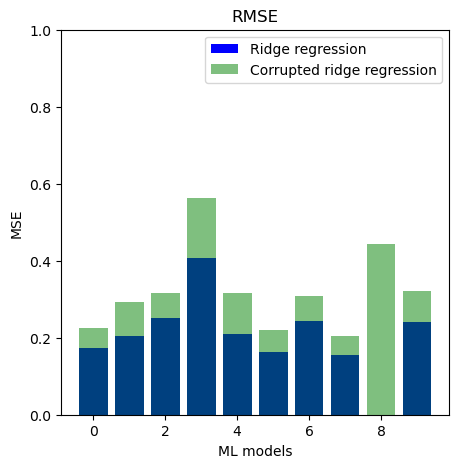

: 

In [ ]:
plt.figure(figsize=(5, 5))
plt.bar(range(rmse.shape[0]), rmse, color='blue', label='Ridge regression')
plt.bar(range(rmse.shape[0]), rmse_low_rank_tmp, color='green', label='Corrupted ridge regression', alpha=0.5)
plt.title('RMSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

: 

In [ ]:
# evaluate the model on normalized test data (this is weird but let's do it)
y_pred_tmp = x_test_yearly @ w_ridge_corrupted
# Compute the mean squared error
rmse_tmp = torch.sqrt(torch.mean((y_pred_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
print(f'  MSE with normalized test data: {rmse_tmp}')
print(f'  MSE with unnormalized test data: {rmse}')

  MSE with normalized test data: [0.2173576  0.29230908 0.2987443  0.5593275  0.31186315 0.19925871
 0.3089795  0.19298406 0.44774443 0.32043976]
  MSE with unnormalized test data: [0.17431763 0.20424017 0.25173718 0.40733692 0.20914215 0.1640997
 0.24260566 0.15507151 0.         0.24035856]


: 

In [ ]:
lambda_tmp = 5000.0
w_ridge_corrupted= {}
w_ridge_low_rank_corrupted = {}

rmse_corrupted_per_model = {}
rmse_low_rank_corrupted_per_model = {}

# training for corrupted data of each climate model
for dir in list(corrupted_data_yearly.keys()):
    print(f'Computing ridge regression for {dir}')

    # merge the corrupted data  and the original data for this specific model 
    x_train_yearly_tmp = data_anomaly_yearly[dir].to(torch.float32).reshape(data_anomaly_yearly[dir].shape[0]*data_anomaly_yearly[dir].shape[1],data_anomaly_yearly[dir].shape[2])    
    y_train_yearly_tmp = data_forced_response_yearly[dir].to(torch.float32).reshape(data_forced_response_yearly[dir].shape[0]*data_forced_response_yearly[dir].shape[1],data_forced_response_yearly[dir].shape[2])

    x_train_tmp = corrupted_data_yearly[dir].to(torch.float32).reshape(corrupted_data_yearly[dir].shape[0]*corrupted_data_yearly[dir].shape[1],corrupted_data_yearly[dir].shape[2])
    y_train_tmp = corrupted_data_yearly_forced_response[dir].to(torch.float32).reshape(corrupted_data_yearly_forced_response[dir].shape[0]*corrupted_data_yearly_forced_response[dir].shape[1],corrupted_data_yearly_forced_response[dir].shape[2])


    # merge the training data 
    x_train_combined = torch.cat([x_train_yearly_tmp, x_train_tmp], dim=0)
    y_train_combined = torch.cat([y_train_yearly_tmp, y_train_tmp], dim=0)
    print(f'  x_train_combined shape: {x_train_combined.shape}')
    print(f'  y_train_combined shape: {y_train_combined.shape}')

    w_ridge_corrupted[dir] = ridge_regression(x_train_combined, y_train_combined, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)
    
    # low rank regression
    U,S,V = torch.linalg.svd(x_train_combined@w_ridge_corrupted[dir],full_matrices=False)

    # # define the rank
    rank = 5

    w_ridge_low_rank_corrupted[dir] = w_ridge_corrupted[dir] @ V[:rank,:].T@V[:rank,:]

    # Evaluate the model on test data
    y_pred_tmp = x_test_yearly @ w_ridge_per_model[dir]
    y_pred_low_rank_tmp= x_test_yearly @ w_ridge_low_rank_per_model[dir]

    # Compute the mean squared error
    rmse_corrupted_per_model[dir] = torch.sqrt(torch.mean((y_pred_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
    rmse_low_rank_corrupted_per_model[dir] = torch.sqrt(torch.mean((y_pred_low_rank_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()


    print(f'  MSE : {rmse_per_model[dir]}')
    print(f'  MSE trace norm: {rmse_low_rank_per_model[dir]}')

Computing ridge regression for CESM2
  x_train_combined shape: torch.Size([13260, 10368])
  y_train_combined shape: torch.Size([13260, 10368])
Loss function:  20203972.0
  MSE : [0.21724398 0.23815152 0.48562115 0.25918385 0.2752391  0.11517038
 0.3268417  0.25263086 0.42665997 0.23860793]
  MSE trace norm: [0.21767604 0.23861048 0.48715    0.2628975  0.27632234 0.11902817
 0.3282846  0.2532912  0.42584088 0.23921932]
Computing ridge regression for CanESM5
  x_train_combined shape: torch.Size([7735, 10368])
  y_train_combined shape: torch.Size([7735, 10368])
Loss function:  33252830.0
  MSE : [0.227794   0.23063353 0.18263617 0.52530223 0.24379663 0.21975331
 0.2702397  0.21782316 0.43994418 0.2671703 ]
  MSE trace norm: [0.22586693 0.22943267 0.19200155 0.5259483  0.24692594 0.2193568
 0.26934072 0.21581644 0.43758035 0.26622373]
Computing ridge regression for MIROC-ES2L
  x_train_combined shape: torch.Size([8840, 10368])
  y_train_combined shape: torch.Size([8840, 10368])
Loss functi

: 

In [ ]:
weights = (1/len(data_anomaly_yearly.keys())) * torch.ones((x_test_yearly.shape[0], len(data_anomaly_yearly.keys())), dtype=torch.float32)
weights_low_rank = (1/len(data_anomaly_yearly.keys())) * torch.ones((x_test_yearly.shape[0], len(data_anomaly_yearly.keys())), dtype=torch.float32)
# assign binary weights = 1 for model CanESM5

weights = torch.zeros((x_test_yearly.shape[0], len(data_anomaly_yearly.keys())), dtype=torch.float32)
weights_low_rank = torch.zeros((x_test_yearly.shape[0], len(data_anomaly_yearly.keys())), dtype=torch.float32)

weights[:, 1] = 1.0
weights_low_rank[:, 1] = 1.0

# weighted predictions
y_pred = x_test_yearly @ w_ridge
y_pred_low_rank = x_test_yearly @ w_ridge_low_rank

y_pred_weighted = torch.zeros_like(x_test_yearly)
y_pred_low_rank_weighted = torch.zeros_like(x_test_yearly)

for idx_m, m in enumerate(data_anomaly_yearly.keys()):
    print(f'Processing model: {m}')
    for i in range(x_test_yearly.shape[0]):
        y_pred_weighted[i, :, :] += weights[i,idx_m ] * (x_test_yearly [i,:, :] @ w_ridge_per_model[m])
        y_pred_low_rank_weighted[i, :, :] += weights[i,idx_m ] * (x_test_yearly[i,:,:] @ w_ridge_low_rank_per_model[m])

# compute the mse between the prediction and the ground truth
rmse_weighted = torch.sqrt(torch.mean((y_pred_weighted - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank_weight =  torch.sqrt(torch.mean((y_pred_low_rank_weighted - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()


print(f'RMSE Ridge Regression: {rmse}')
print(f'RMSE Low Rank Ridge Regression: {rmse_low_rank}')
print(f'RMSE Weighted Ridge Regression: {rmse_weighted}')
print(f'RMSE Weighted Low Rank Ridge Regression: {rmse_low_rank_weight}')

Processing model: CESM2
Processing model: CanESM5
Processing model: MIROC-ES2L
Processing model: MIROC6
Processing model: MPI-ESM1-2-LR
RMSE Ridge Regression: [0.17431763 0.20424017 0.25173718 0.40733692 0.20914215 0.1640997
 0.24260566 0.15507151 0.         0.24035856]
RMSE Low Rank Ridge Regression: [0.17885357 0.2052549  0.26803577 0.41344923 0.22129339 0.1837789
 0.24196193 0.16467954 0.         0.23973066]
RMSE Weighted Ridge Regression: [0.227794   0.23063353 0.18263617 0.52530223 0.24379663 0.21975331
 0.2702397  0.21782316 0.43994418 0.2671703 ]
RMSE Weighted Low Rank Ridge Regression: [0.22586693 0.22943267 0.19200155 0.5259483  0.24692594 0.2193568
 0.26934072 0.21581644 0.43758035 0.26622373]


: 

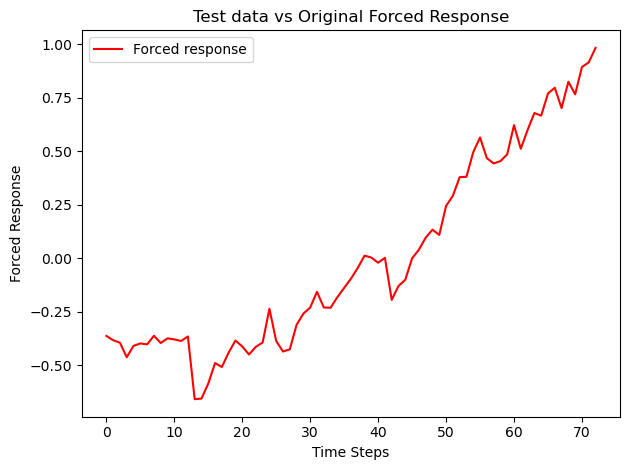

: 

In [ ]:
# plot test data vs the predicted data
import matplotlib.pyplot as plt

idx_cell = 150  # index of the grid cell to plot
idx_run = 2 # index of the run to plot
idx_lon = 30
idx_lat = 30

plt.subplot(1, 1, 1)
plt.plot(y_test_yearly.reshape(y_pred.shape[0], y_pred.shape[1],latitude.shape[0],longitude.shape[0])[idx_run,:,idx_lat,idx_lon], label='Forced response', color='red')
plt.title('Test data vs Original Forced Response')
plt.xlabel('Time Steps')
plt.ylabel('Forced Response')
plt.legend()


plt.tight_layout()
plt.show()